# Plant Disease Classification using CNN

## Problem Statement

Plant diseases can spread quickly and cause significant losses in agricultural production. Early identification of diseases from leaf images can help farmers take timely action.

## Need

A system that can:

- Automatically analyze tomato leaf images
- Identify disease patterns from leaf photographs
- Classify leaves into different disease categories
- Help detect diseases at an early stage

## Project Objectives

The system should:

- Analyze tomato leaf images automatically
- Learn visual patterns associated with plant diseases
- Classify images into 6 classes:
  - Early Blight
  - Healthy
  - Late Blight
  - Leaf Mold
  - Septoria Leaf Spot
  - Yellow Curl Virus
- Use a Convolutional Neural Network (CNN) for image classification
- Evaluate the model using validation accuracy and a confusion matrix

## Approach Overview

Traditional image classification methods often require manually designed features such as color, texture, or shape.

## Traditional Methods

- Handcrafted image features
- Manually designed rules
- Limited ability to generalize
- Requires domain-specific feature engineering

## CNN-Based Approach

- Learns useful features directly from images
- Detects spatial patterns such as edges, textures, and disease symptoms
- Automatically extracts hierarchical visual features
- Can generalize to previously unseen leaf images

## Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch.optim as optim

## Dataset Loading

The plant disease dataset is provided as a ZIP file.

We upload the dataset to Google Colab and extract it into the `dataset` directory.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'dataset.zip', 'sample_data']


In [ ]:
import zipfile
import os

zip_path = next(
    file for file in os.listdir("/content")
    if file.endswith(".zip")
)

with zipfile.ZipFile("/content/" + zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")
print(os.listdir("/content/dataset"))

Dataset extracted successfully!
['Septoria_Leaf_Spot', '.DS_Store', 'Yellow_Curl_Virus', 'Late_Blight', 'Early_Blight', 'Leaf_Mold', 'Healthy']


In [ ]:
import os

dataset_path = "/content/dataset"

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        images = [
            file for file in os.listdir(class_path)
            if file.lower().endswith(".jpg")
        ]

        print(f"{class_name}: {len(images)} images")

Early_Blight: 250 images
Healthy: 250 images
Late_Blight: 250 images
Leaf_Mold: 250 images
Septoria_Leaf_Spot: 250 images
Yellow_Curl_Virus: 250 images


In [ ]:
class_names = [
    "Early_Blight",
    "Healthy",
    "Late_Blight",
    "Leaf_Mold",
    "Septoria_Leaf_Spot",
    "Yellow_Curl_Virus"
]

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

print(class_to_idx)

{'Early_Blight': 0, 'Healthy': 1, 'Late_Blight': 2, 'Leaf_Mold': 3, 'Septoria_Leaf_Spot': 4, 'Yellow_Curl_Virus': 5}


## Dataset Overview

The dataset contains real tomato leaf photographs organized into six folders.

Each folder represents one class:

- Early_Blight
- Healthy
- Late_Blight
- Leaf_Mold
- Septoria_Leaf_Spot
- Yellow_Curl_Virus

There are 250 images per class, giving a total of 1,500 images.

In [ ]:
dataset_path = "/content/dataset"

print("Dataset folders:")
print(os.listdir(dataset_path))

Dataset folders:
['Septoria_Leaf_Spot', '.DS_Store', 'Yellow_Curl_Virus', 'Late_Blight', 'Early_Blight', 'Leaf_Mold', 'Healthy']


In [ ]:
class_names = [
    "Early_Blight",
    "Healthy",
    "Late_Blight",
    "Leaf_Mold",
    "Septoria_Leaf_Spot",
    "Yellow_Curl_Virus"
]

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(".jpg")
    ]

    print(f"{class_name}: {len(images)} images")

Early_Blight: 250 images
Healthy: 250 images
Late_Blight: 250 images
Leaf_Mold: 250 images
Septoria_Leaf_Spot: 250 images
Yellow_Curl_Virus: 250 images


## Build DataFrame

We iterate through each class folder and collect:

- Image path
- Class name

A Pandas DataFrame makes it easier to explore, split, and manage the dataset.

In [ ]:
data = []

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)

    for img in os.listdir(class_path):
        if img.lower().endswith(".jpg"):
            img_path = os.path.join(class_path, img)

            data.append([img_path, class_name])

df = pd.DataFrame(data, columns=["image_path", "label"])

In [ ]:
df.head()

,image_path,label
0,/content/dataset/Early_Blight/early_blight_206...,Early_Blight
1,/content/dataset/Early_Blight/early_blight_208...,Early_Blight
2,/content/dataset/Early_Blight/early_blight_000...,Early_Blight
3,/content/dataset/Early_Blight/early_blight_096...,Early_Blight
4,/content/dataset/Early_Blight/early_blight_139...,Early_Blight


## Check the Data

We check the total number of images and the number of images in each class.

A balanced dataset is useful because the model gets a similar number of examples from every class.

In [ ]:
print("Total images:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

Total images: 1500

Class distribution:
label
Early_Blight          250
Healthy               250
Late_Blight           250
Leaf_Mold             250
Septoria_Leaf_Spot    250
Yellow_Curl_Virus     250
Name: count, dtype: int64


## Visualise Sample Images

We inspect sample images from each class to verify that the images are loading correctly and that the folder names correspond to the expected labels.

We display two images from each class so that all six classes are represented.

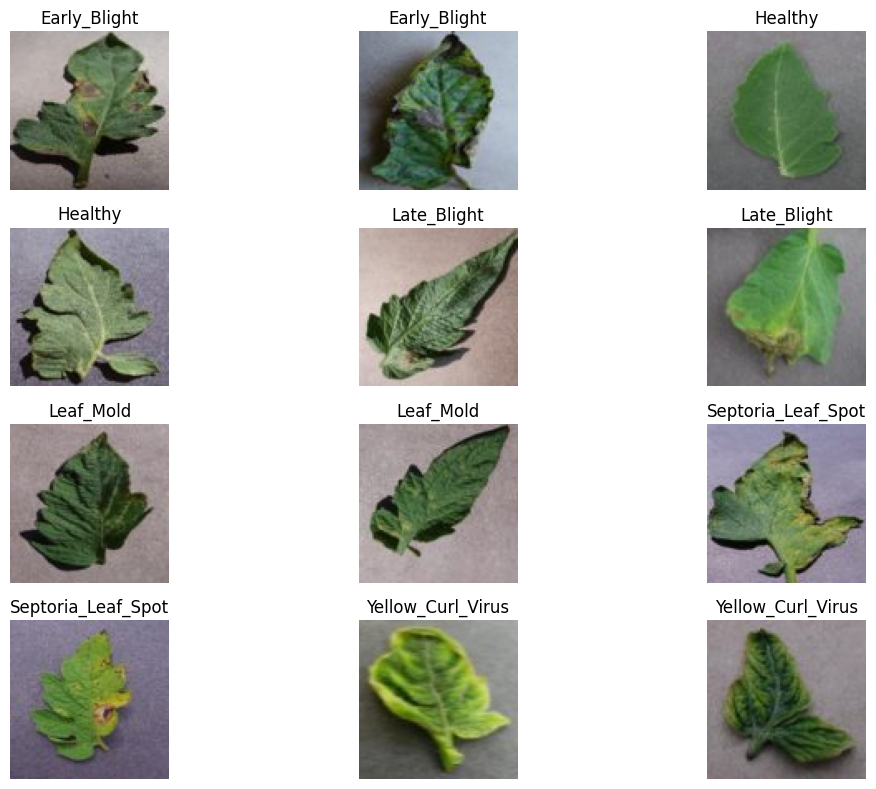

In [ ]:
plt.figure(figsize=(12, 8))

i = 1

for cls in class_names:
    sample_df = df[df["label"] == cls].sample(2, random_state=42)

    for _, row in sample_df.iterrows():
        img = Image.open(row["image_path"])

        plt.subplot(4, 3, i)
        plt.imshow(img)
        plt.title(row["label"])
        plt.axis("off")

        i += 1

plt.tight_layout()

## Label Encoding

The neural network cannot directly work with text labels.

Therefore, we convert each class name into an integer label.

The assignment requires the following exact ordering:

- Early_Blight → 0
- Healthy → 1
- Late_Blight → 2
- Leaf_Mold → 3
- Septoria_Leaf_Spot → 4
- Yellow_Curl_Virus → 5

In [ ]:
label_map = {
    "Early_Blight": 0,
    "Healthy": 1,
    "Late_Blight": 2,
    "Leaf_Mold": 3,
    "Septoria_Leaf_Spot": 4,
    "Yellow_Curl_Virus": 5
}

label_map

{'Early_Blight': 0,
 'Healthy': 1,
 'Late_Blight': 2,
 'Leaf_Mold': 3,
 'Septoria_Leaf_Spot': 4,
 'Yellow_Curl_Virus': 5}

In [ ]:
df["label_id"] = df["label"].map(label_map)

df.head()

,image_path,label,label_id
0,/content/dataset/Early_Blight/early_blight_206...,Early_Blight,0
1,/content/dataset/Early_Blight/early_blight_208...,Early_Blight,0
2,/content/dataset/Early_Blight/early_blight_000...,Early_Blight,0
3,/content/dataset/Early_Blight/early_blight_096...,Early_Blight,0
4,/content/dataset/Early_Blight/early_blight_139...,Early_Blight,0


## Dataset Split

We split the dataset into:

- 80% training data
- 20% validation data

Stratification is used to preserve the same class distribution in both sets.

The training set is used to learn the disease patterns, while the validation set is used to evaluate how well the model generalizes to images it has not seen during training.

In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [ ]:
print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 1200
Validation size: 300


### Check Distribution

In [ ]:
print("Training distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

Training distribution:
label
Leaf_Mold             200
Septoria_Leaf_Spot    200
Late_Blight           200
Early_Blight          200
Healthy               200
Yellow_Curl_Virus     200
Name: count, dtype: int64

Validation distribution:
label
Late_Blight           50
Early_Blight          50
Leaf_Mold             50
Yellow_Curl_Virus     50
Healthy               50
Septoria_Leaf_Spot    50
Name: count, dtype: int64


## Image Preprocessing

Before feeding images into the CNN, we prepare them in the same format expected by the evaluation system.

We:

- Convert images to RGB
- Resize them to 64 × 64 pixels
- Convert pixel values to NumPy arrays
- Scale pixel values from 0–255 to 0–1

The final image format will contain 3 channels:

- Red
- Green
- Blue

The CNN will receive images in the format:

`(N, 3, 64, 64)`

In [ ]:
IMG_SIZE = 64

def preprocess_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img = np.array(img) / 255.0

    return img

In [ ]:
sample_img = preprocess_image(train_df["image_path"].iloc[0])

print("Processed image shape:", sample_img.shape)

Processed image shape: (64, 64, 3)


### Visualize Processed Image

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

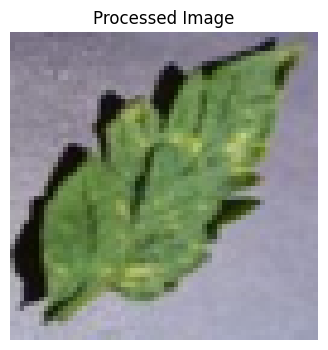

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title("Processed Image")
plt.axis("off")

## Custom Dataset

We create a custom PyTorch Dataset that loads and preprocesses images when they are requested.

Each item returned by the dataset contains:

- Image tensor
- Integer class label

The image is converted from:

`(64, 64, 3)`

to PyTorch's required format:

`(3, 64, 64)`

In [ ]:
class PlantDiseaseDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label"]

        # Load image as RGB
        img = Image.open(img_path).convert("RGB")

        # Resize
        img = img.resize((IMG_SIZE, IMG_SIZE))

        # Convert to NumPy array and scale to 0-1
        img = np.array(img) / 255.0

        # Change from (H, W, C) to (C, H, W)
        img = np.transpose(img, (2, 0, 1))

        # Convert to PyTorch tensor
        img = torch.tensor(img, dtype=torch.float32)

        # Convert label to integer tensor
        label = torch.tensor(label_map[label], dtype=torch.long)

        return img, label

### Verify Dataset Loading

In [ ]:
train_dataset = PlantDiseaseDataset(train_df)

img, label = train_dataset[0]

print("Image shape:", img.shape)
print("Label:", label)

Image shape: torch.Size([3, 64, 64])
Label: tensor(3)


## Create DataLoader

DataLoader groups individual images into batches.

We use:

- Batch size = 32
- `shuffle=True` for training so that the model sees the training examples in a different order
- `shuffle=False` for validation so that evaluation remains consistent

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [ ]:
val_dataset = PlantDiseaseDataset(val_df)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

### Verify Batch Shape

We verify that the DataLoader produces batches with the correct shape.

The expected image batch shape is:

`(32, 3, 64, 64)`

The expected label shape is:

`(32,)`

In [ ]:
for images, labels in train_loader:
    print("Images:", images.shape)
    print("Labels:", labels.shape)
    break

Images: torch.Size([32, 3, 64, 64])
Labels: torch.Size([32])


## CNN Model Architecture

The CNN consists of two main parts:

### Feature Extraction

Convolution and pooling layers learn visual patterns such as:

- Edges
- Textures
- Leaf structures
- Spots
- Color patterns
- Disease-related regions

### Classification

Fully connected layers use the extracted features to predict one of the six plant disease classes.

The model takes an input of:

`(3, 64, 64)`

and produces six output scores, one for each class.

In [ ]:
class PlantDiseaseCNN(nn.Module):

    def __init__(self):
        super(PlantDiseaseCNN, self).__init__()

        # Convolution Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)

        # Convolution Block 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # Convolution Block 3
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.relu = nn.ReLU()

        # 64x64 -> 32x32 -> 16x16 -> 8x8
        self.fc1 = nn.Linear(128 * 8 * 8, 128)

        self.dropout = nn.Dropout(0.5)

        # Six output classes
        self.fc2 = nn.Linear(128, 6)

    def forward(self, x):

        # Block 1
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)

        # Block 2
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool(x)

        # Block 3
        x = self.relu(self.conv5(x))
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        # Output
        x = self.fc2(x)

        return x

## Initialize Model

Model Flow:

```text
Input (3, 64, 64)
        ↓
Conv(32) → ReLU → Conv(32) → ReLU → MaxPool
        ↓
Conv(64) → ReLU → Conv(64) → ReLU → MaxPool
        ↓
Conv(128) → ReLU → MaxPool
        ↓
Flatten
        ↓
Dense(128) → ReLU → Dropout(0.5)
        ↓
Output(6)

In [ ]:
model = PlantDiseaseCNN()

print(model)

PlantDiseaseCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=8192, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)


### Test with One Batch

The final layer contains six neurons, corresponding to the six plant disease classes.

The output contains raw scores called logits.

`CrossEntropyLoss` will use these logits directly during training.

In [ ]:
for images, labels in train_loader:

    outputs = model(images)

    print("Input shape:", images.shape)
    print("Output shape:", outputs.shape)

    break

Input shape: torch.Size([32, 3, 64, 64])
Output shape: torch.Size([32, 6])


## Training Setup

### Loss Function

We use CrossEntropyLoss because this is a multi-class classification problem.

The model predicts one of six mutually exclusive classes.

In [ ]:
criterion = nn.CrossEntropyLoss()

### Optimizer

We use the Adam optimizer with a learning rate of 0.001.

Adam automatically adjusts the learning rate for different model parameters and usually works well for CNN training.

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Device

We use the GPU when it is available because CNN training can be significantly faster on a GPU.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


---
# Train the Model

We train the CNN for multiple epochs.

During each epoch:

1. The model learns from the training images.
2. Training loss and accuracy are calculated.
3. The model is evaluated on the validation set.
4. Validation loss and accuracy are recorded.
5. The best-performing model is saved.

Tracking validation performance helps us identify whether the model is generalizing well to unseen images.

## Saving the Best Model

The validation accuracy can increase or decrease during training.

Therefore, instead of keeping only the final epoch, we save the model whenever validation accuracy improves.

This gives us the best-performing version of the CNN during training.

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

epochs = 15
best_val_acc = 0

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = train_loss / len(train_loader)
    train_acc = correct / total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    # Store history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_plant_disease_model.pth"
        )

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/15] | Train Loss: 1.7440 | Train Acc: 0.2117 | Val Loss: 1.6652 | Val Acc: 0.2633
Epoch [2/15] | Train Loss: 1.5028 | Train Acc: 0.3775 | Val Loss: 1.2994 | Val Acc: 0.5067
Epoch [3/15] | Train Loss: 1.2675 | Train Acc: 0.5017 | Val Loss: 1.2188 | Val Acc: 0.5100
Epoch [4/15] | Train Loss: 1.1609 | Train Acc: 0.5550 | Val Loss: 1.0292 | Val Acc: 0.6200
Epoch [5/15] | Train Loss: 1.0489 | Train Acc: 0.6083 | Val Loss: 0.9981 | Val Acc: 0.6033
Epoch [6/15] | Train Loss: 1.0222 | Train Acc: 0.6033 | Val Loss: 0.9176 | Val Acc: 0.6367
Epoch [7/15] | Train Loss: 0.8998 | Train Acc: 0.6608 | Val Loss: 0.9768 | Val Acc: 0.6267
Epoch [8/15] | Train Loss: 0.8176 | Train Acc: 0.6758 | Val Loss: 1.0161 | Val Acc: 0.6100
Epoch [9/15] | Train Loss: 0.7680 | Train Acc: 0.7108 | Val Loss: 0.7944 | Val Acc: 0.7200
Epoch [10/15] | Train Loss: 0.6633 | Train Acc: 0.7450 | Val Loss: 1.0672 | Val Acc: 0.6500
Epoch [11/15] | Train Loss: 0.6644 | Train Acc: 0.7483 | Val Loss: 0.7056 | Val Acc: 0.74

## Data Augmentation

The dataset contains only 1,500 images, so the CNN may overfit to the training examples.

To improve generalization, we apply random transformations to training images such as:

- Horizontal flipping
- Small rotations
- Small changes in brightness and contrast

These transformations create slightly different versions of the same leaf during training.

Validation images are not augmented because validation should represent the original data distribution.

In [ ]:
from torchvision import transforms

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

##Improved Dataset Class

In [ ]:
class PlantDiseaseDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label"]

        # Load image as RGB
        img = Image.open(img_path).convert("RGB")

        # Apply transformations
        if self.transform:
            img = self.transform(img)

        # Convert label to integer
        label = torch.tensor(
            label_map[label],
            dtype=torch.long
        )

        return img, label

##Recreate Dataset and DataLoaders

In [ ]:
train_dataset = PlantDiseaseDataset(
    train_df,
    transform=train_transform
)

val_dataset = PlantDiseaseDataset(
    val_df,
    transform=val_transform
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

## Improved CNN Architecture

We use a deeper CNN with Batch Normalization and Dropout.

Batch Normalization helps stabilize the learning process, while Dropout helps reduce overfitting.

Instead of flattening a large feature map into a very large fully connected layer, Global Average Pooling reduces the spatial dimensions before classification.

The final layer contains six neurons, corresponding to the six plant disease classes.

In [ ]:
class ImprovedPlantDiseaseCNN(nn.Module):

    def __init__(self):
        super(ImprovedPlantDiseaseCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.20),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.30)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Dropout(0.40),

            nn.Linear(128, 6)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = self.classifier(x)

        return x

In [ ]:
model = ImprovedPlantDiseaseCNN()

model = model.to(device)

print(model)

ImprovedPlantDiseaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(

In [ ]:
for images, labels in train_loader:

    images = images.to(device)

    outputs = model(images)

    print("Input shape:", images.shape)
    print("Output shape:", outputs.shape)

    break

Input shape: torch.Size([32, 3, 64, 64])
Output shape: torch.Size([32, 6])


## Training Setup

We use:

- CrossEntropyLoss for multi-class classification
- Adam optimizer for parameter updates
- A learning-rate scheduler to gradually reduce the learning rate when validation performance stops improving
- GPU acceleration when available

The best model based on validation accuracy will be saved.

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

epochs = 25
best_val_acc = 0

for epoch in range(epochs):

    # =========================
    # Training
    # =========================

    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predictions = torch.max(outputs, 1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predictions = torch.max(outputs, 1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total


    # Store results

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)


    # Learning-rate scheduler

    scheduler.step(val_acc)


    # Save best model

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_plant_disease_model.pth"
        )


    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

Epoch [1/25] | Train Loss: 1.4399 | Train Acc: 0.4492 | Val Loss: 1.4379 | Val Acc: 0.4200 | LR: 0.001000
Epoch [2/25] | Train Loss: 1.1180 | Train Acc: 0.5608 | Val Loss: 1.2884 | Val Acc: 0.5267 | LR: 0.001000
Epoch [3/25] | Train Loss: 0.9517 | Train Acc: 0.6325 | Val Loss: 1.0735 | Val Acc: 0.5500 | LR: 0.001000
Epoch [4/25] | Train Loss: 0.8764 | Train Acc: 0.6683 | Val Loss: 1.1414 | Val Acc: 0.5433 | LR: 0.001000
Epoch [5/25] | Train Loss: 0.8298 | Train Acc: 0.7058 | Val Loss: 1.1285 | Val Acc: 0.5967 | LR: 0.001000
Epoch [6/25] | Train Loss: 0.7190 | Train Acc: 0.7275 | Val Loss: 1.6422 | Val Acc: 0.5667 | LR: 0.001000
Epoch [7/25] | Train Loss: 0.6611 | Train Acc: 0.7533 | Val Loss: 0.8197 | Val Acc: 0.6700 | LR: 0.001000
Epoch [8/25] | Train Loss: 0.6804 | Train Acc: 0.7475 | Val Loss: 1.9670 | Val Acc: 0.4567 | LR: 0.001000
Epoch [9/25] | Train Loss: 0.6585 | Train Acc: 0.7625 | Val Loss: 0.4806 | Val Acc: 0.7933 | LR: 0.001000
Epoch [10/25] | Train Loss: 0.5923 | Train Acc

## Load the Best Model

During training, the model with the highest validation accuracy was saved.

We reload that model so that all final evaluation results are based on the best-performing CNN rather than necessarily the final epoch.

In [ ]:
# Load the best-performing model

model.load_state_dict(
    torch.load(
        "best_plant_disease_model.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")

Best Validation Accuracy: 90.67%


## Validation Evaluation

The best-performing model is evaluated on the complete validation dataset.

The validation set contains 300 images that were not used during training.

We calculate the predictions for every validation image and use them to measure the final validation accuracy.

In [ ]:
# Evaluate the best model on the complete validation set

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate validation accuracy
accuracy = accuracy_score(all_labels, all_preds)

print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Validation Accuracy: 90.67%


### Validation Results

The model's predictions are compared with the actual labels from the complete validation set.

A high validation accuracy indicates that the CNN has learned useful visual patterns for distinguishing between the six plant disease classes.

In [ ]:
print("Number of validation images:", len(all_labels))
print("Correct predictions:", sum(np.array(all_preds) == np.array(all_labels)))
print("Incorrect predictions:", sum(np.array(all_preds) != np.array(all_labels)))
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Number of validation images: 300
Correct predictions: 272
Incorrect predictions: 28
Validation Accuracy: 90.67%


## Training and Validation Performance

We visualize the training and validation performance across all epochs.

### Loss Plot

The loss plot shows how the model's prediction error changes during training.

- Training Loss: Loss calculated on the training dataset
- Validation Loss: Loss calculated on the validation dataset

A decreasing loss generally indicates that the model is learning.

### Accuracy Plot

The accuracy plot shows how classification performance changes during training.

- Training Accuracy: Accuracy on the training dataset
- Validation Accuracy: Accuracy on the validation dataset

Comparing training and validation performance helps us identify whether the model is learning effectively or overfitting.

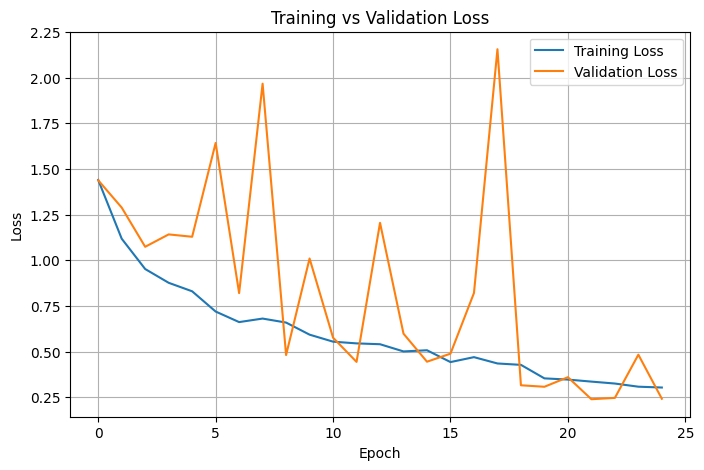

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

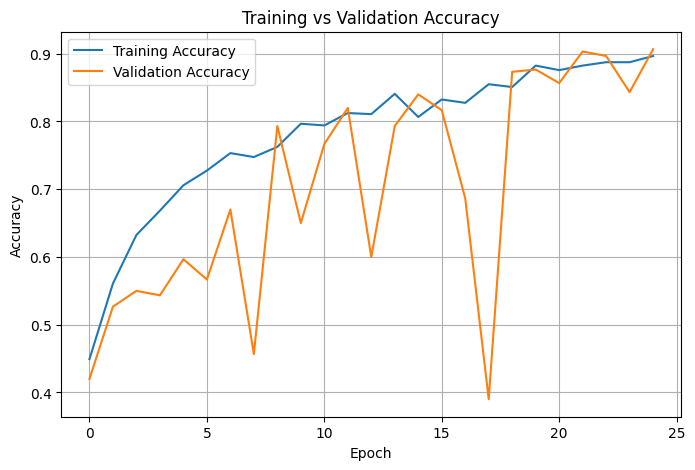

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

## Confusion Matrix

A confusion matrix provides a detailed view of the model's classification performance.

The rows represent the actual classes, while the columns represent the predicted classes.

The diagonal values represent correctly classified images, while values outside the diagonal represent misclassifications.

The confusion matrix is calculated using the complete validation dataset.

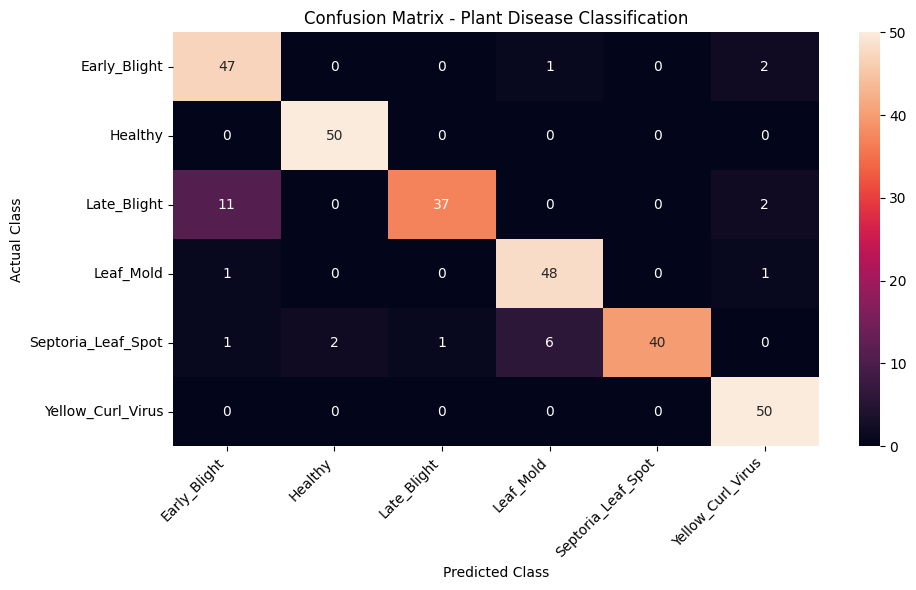

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Plant Disease Classification")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

### Classification Report

The classification report provides class-wise evaluation metrics:

- Precision: How many predicted samples for a class were actually correct
- Recall: How many actual samples of a class were correctly identified
- F1-score: Balance between precision and recall
- Support: Number of validation samples belonging to each class

In [ ]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

                    precision    recall  f1-score   support

      Early_Blight       0.78      0.94      0.85        50
           Healthy       0.96      1.00      0.98        50
       Late_Blight       0.97      0.74      0.84        50
         Leaf_Mold       0.87      0.96      0.91        50
Septoria_Leaf_Spot       1.00      0.80      0.89        50
 Yellow_Curl_Virus       0.91      1.00      0.95        50

          accuracy                           0.91       300
         macro avg       0.92      0.91      0.91       300
      weighted avg       0.92      0.91      0.91       300



## Predicted vs Actual Labels

We visualize several validation images together with their predicted and actual classes.

This provides a qualitative evaluation of the CNN.

- Green title: Correct prediction
- Red title: Incorrect prediction

The images are taken from the validation set, which the model did not use during training.

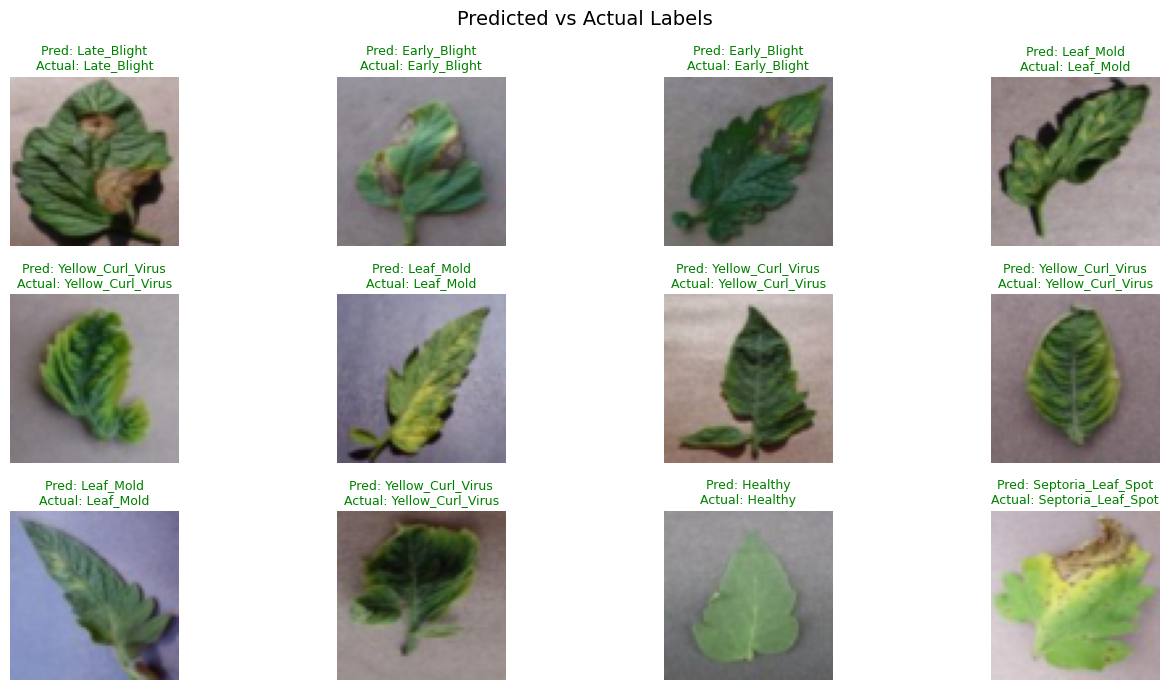

In [ ]:
# Display predicted vs actual labels

model.eval()

images, labels = next(iter(val_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():

    outputs = model(images)

    predictions = torch.argmax(outputs, dim=1)

plt.figure(figsize=(14, 7))

for i in range(min(12, len(images))):

    img = images[i].cpu().numpy()

    # Convert from (C, H, W) to (H, W, C)
    img = np.transpose(img, (1, 2, 0))

    predicted_class = class_names[predictions[i].item()]
    actual_class = class_names[labels[i].item()]

    plt.subplot(3, 4, i + 1)

    plt.imshow(img)

    if predictions[i] == labels[i]:
        title_color = "green"
    else:
        title_color = "red"

    plt.title(
        f"Pred: {predicted_class}\nActual: {actual_class}",
        color=title_color,
        fontsize=9
    )

    plt.axis("off")

plt.suptitle(
    "Predicted vs Actual Labels",
    fontsize=14
)

plt.tight_layout()

# Final Results

The Plant Disease Classification CNN was successfully trained to classify tomato leaf images into six different classes.

### Classes

1. Early_Blight
2. Healthy
3. Late_Blight
4. Leaf_Mold
5. Septoria_Leaf_Spot
6. Yellow_Curl_Virus

### Model

The final CNN uses:

- Convolutional layers
- Batch Normalization
- ReLU activation
- Max Pooling
- Dropout
- Global Average Pooling
- Fully Connected layers

Data augmentation was applied to the training images to improve generalization.

The model was trained using the Adam optimizer and CrossEntropyLoss.

The best-performing model was selected using validation accuracy.

In [ ]:
# Final model performance

print("=" * 50)
print("FINAL RESULTS")
print("=" * 50)

print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"Validation Accuracy:      {accuracy * 100:.2f}%")

print("\nClass Mapping:")
for label, class_name in enumerate(class_names):
    print(f"{label} → {class_name}")

print("\nModel: ImprovedPlantDiseaseCNN")
print("Input Shape: (3, 64, 64)")
print("Output Classes: 6")
print("Training Images:", len(train_df))
print("Validation Images:", len(val_df))

print("=" * 50)

FINAL RESULTS
Best Validation Accuracy: 90.67%
Validation Accuracy:      90.67%

Class Mapping:
0 → Early_Blight
1 → Healthy
2 → Late_Blight
3 → Leaf_Mold
4 → Septoria_Leaf_Spot
5 → Yellow_Curl_Virus

Model: ImprovedPlantDiseaseCNN
Input Shape: (3, 64, 64)
Output Classes: 6
Training Images: 1200
Validation Images: 300


### Save Trained Model

The trained CNN is saved so that it can be reused later without retraining the model from the beginning.

In [ ]:
# Save the trained model

model_path = "plant_disease_cnn_model.pth"

torch.save(
    model.state_dict(),
    model_path
)

print(f"Model saved successfully as: {model_path}")

Model saved successfully as: plant_disease_cnn_model.pth


## Conclusion

A Convolutional Neural Network was developed to classify tomato leaf images into six disease categories.

The complete pipeline included:

- Dataset loading and exploration
- Class distribution analysis
- Image visualization
- Label encoding
- Train-validation splitting
- Image resizing and normalization
- Data augmentation
- Custom PyTorch Dataset
- DataLoader creation
- CNN architecture design
- Model training
- Validation evaluation
- Confusion matrix analysis
- Classification report
- Prediction visualization

The best model achieved a validation accuracy of approximately **90.67%**, which is well above the required **60% accuracy** threshold.

The trained model was saved for future use.